# Colab 01 — ¿Por qué no medimos todos lo mismo?

**Laboratorio 1 · Departamento de Física · FCEN-UBA**

Clase 1 — 12/08

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/charlyacha/Labo1-colabs/blob/main/01_Primeros_pasos_medir_y_reportar.ipynb)

En esta clase midieron la misma pieza varias personas y con tres instrumentos distintos, y salieron números distintos. Acá vamos a cargar esos números, mirarlos y empezar a contestar la pregunta.

**Al terminar este cuaderno vas a poder:** ejecutar código en Colab, guardar tus mediciones en un arreglo de numpy, hacer un gráfico presentable y decidir cuántos dígitos tiene sentido escribir.

---

### Antes de tocar nada

Andá a **Archivo → Guardar una copia en Drive**. Vas a trabajar sobre tu copia:
lo que escribas acá sin copiar primero no se guarda en ningún lado.

Este cuaderno se recorre **de arriba hacia abajo**. Las celdas no son
independientes: cada una usa lo que definieron las anteriores. Si algo tira
`NameError`, casi siempre es porque salteaste una celda.

### 1. El entorno: qué es esto que estás mirando

Un cuaderno de Colab es una sucesión de **celdas**. Hay de dos tipos:

- **celdas de texto**, como ésta, que solo se leen;
- **celdas de código**, que se ejecutan con `Shift + Enter` o con el botón ▶.

Lo único raro al principio es que **el orden importa**: el cuaderno recuerda
todo lo que ejecutaste, en el orden en que lo hiciste. Si volvés arriba y
cambiás una celda, las de abajo no se enteran hasta que las corras de nuevo.
Cuando algo se pone confuso, `Entorno de ejecución → Reiniciar y ejecutar
todo` deja el cuaderno en un estado limpio y reproducible. Ese, y no otro,
es el estado en el que tiene que estar el cuaderno que entregues.

Corré la celda que sigue. Es la única celda de preparación y va en todos los
cuadernos del curso.

In [1]:
import os

if not os.path.exists("lab1_utils.py"):
    !wget -q -O lab1_utils.py https://raw.githubusercontent.com/charlyacha/Labo1-colabs/main/lab1_utils.py

import numpy as np
import matplotlib.pyplot as plt
import lab1_utils as lab

lab.estilo_lab1()
print("Listo. numpy", np.__version__)

Listo. numpy 2.0.2


### 2. Variables y tipos

Una variable es un nombre pegado a un valor. En Python no hace falta declarar
de qué tipo es: lo deduce solo.

In [2]:
largo = 12.7
unidad = "cm"
cantidad_de_mediciones = 6

print(largo, type(largo))
print(unidad, type(unidad))
print(cantidad_de_mediciones, type(cantidad_de_mediciones))

12.7 <class 'float'>
cm <class 'str'>
6 <class 'int'>


Para imprimir resultados mezclados con texto conviene usar **f-strings**: una
`f` antes de las comillas habilita escribir expresiones entre llaves.

In [3]:
print(f"Medí {largo} {unidad} en {cantidad_de_mediciones} intentos.")

# El formato después de los dos puntos controla cuántos decimales se muestran.
print(f"Con dos decimales: {largo:.2f} {unidad}")
print(f"En notación científica: {largo:.3e} {unidad}")

Medí 12.7 cm en 6 intentos.
Con dos decimales: 12.70 cm
En notación científica: 1.270e+01 cm


### 3. Listas y arreglos: por qué no da lo mismo

Python trae las **listas**, que sirven para guardar cualquier cosa. Pero para
hacer cuentas usamos los **arreglos** de numpy (`np.array`), y la razón es
concreta: con un arreglo, una operación se aplica a todos los elementos de
una sola vez. Eso se llama *vectorización* y es lo que hace que el código de
análisis de datos sea corto y legible.

Mirá la diferencia.

In [4]:
lista = [12.7, 12.8, 12.6, 12.9, 12.7, 12.5]
arreglo = np.array(lista)

print("lista * 2   ->", lista * 2)
print("arreglo * 2 ->", arreglo * 2)

lista * 2   -> [12.7, 12.8, 12.6, 12.9, 12.7, 12.5, 12.7, 12.8, 12.6, 12.9, 12.7, 12.5]
arreglo * 2 -> [25.4 25.6 25.2 25.8 25.4 25. ]


La lista se **repitió**; el arreglo se **multiplicó**. Esa es la diferencia
que importa. Todo lo que midas en este curso va a vivir en un `np.array`.

In [5]:
# Seis personas midieron el mismo cilindro con el mismo calibre.
# Reemplazá estos números por los de tu grupo.
diametro_calibre = np.array([21.45, 21.50, 21.40, 21.55, 21.45, 21.55])

print("mediciones:", diametro_calibre)
print("cantidad:", len(diametro_calibre))
print("mínimo y máximo:", diametro_calibre.min(), diametro_calibre.max())
print("rango:", diametro_calibre.max() - diametro_calibre.min())

mediciones: [21.45 21.5  21.4  21.55 21.45 21.55]
cantidad: 6
mínimo y máximo: 21.4 21.55
rango: 0.15000000000000213


Si en la celda anterior el rango te salió `0.15000000000000213` en lugar de
`0.15`, no te asustes: no es un error tuyo ni de numpy. Es que la computadora
guarda los números decimales en binario y muchos no tienen representación
exacta, igual que 1/3 no la tiene en decimal. El error es del orden de
$10^{-16}$, o sea diecisiete órdenes de magnitud por debajo de tu incerteza
experimental. Lo mencionamos para que sepas de dónde salen esas colas de
dígitos, no porque importe.

### 4. Las tres mediciones, los tres instrumentos

Ahora cargamos lo mismo medido con regla, calibre y micrómetro. Fijate que
cada instrumento tiene su **resolución**: el mínimo intervalo que permite
distinguir. La regla milimetrada aprecia 1 mm, el calibre 0,05 mm, el
micrómetro 0,01 mm.

In [6]:
regla      = np.array([21.0, 21.5, 21.0, 22.0, 21.5, 21.5])
calibre    = np.array([21.45, 21.50, 21.40, 21.55, 21.45, 21.55])
microm     = np.array([21.462, 21.458, 21.471, 21.455, 21.464, 21.469])

resolucion = {"regla": 1.0, "calibre": 0.05, "micrómetro": 0.01}

for nombre, datos in [("regla", regla), ("calibre", calibre),
                      ("micrómetro", microm)]:
    dispersion = datos.max() - datos.min()
    print(f"{nombre:<12} promedio = {datos.mean():.4f} mm   "
          f"rango = {dispersion:.3f} mm   resolución = {resolucion[nombre]} mm")

regla        promedio = 21.4167 mm   rango = 1.000 mm   resolución = 1.0 mm
calibre      promedio = 21.4833 mm   rango = 0.150 mm   resolución = 0.05 mm
micrómetro   promedio = 21.4632 mm   rango = 0.016 mm   resolución = 0.01 mm


Pará acá un segundo, porque este cuadro contiene un punto fundamental de la clase.

Con la regla, la dispersión entre observadores es **del orden de la
resolución**: todos leen lo mismo salvo por el último dígito, que estiman a
ojo. Con el micrómetro, la dispersión es **varias veces la resolución**: el
instrumento distingue mucho mejor de lo que el objeto y el procedimiento
permiten reproducir. Ahí la incerteza ya no la fija el instrumento sino la
medición misma —cuánto apretás el micrómetro, dónde apoyás, si el cilindro
es realmente cilíndrico—.

**Moraleja operativa:** la incerteza de una medición es la mayor entre la
resolución del instrumento y la dispersión observada al repetirla. Cuantificar
esa dispersión es el tema de la Clase 2.

### 5. Tu primer gráfico

Y acá van las **siete reglas de graficación** del curso. No son sugerencias:
se exigen desde el primer informe.

1. Todo eje lleva **magnitud y unidad**. `Tiempo (s)`, no `t`.
2. Los datos experimentales se **marcan, no se unen**. La línea que une puntos
   medidos afirma que hay algo entre ellos, y el experimento no lo midió.
3. La línea es del **modelo**, y se dibuja sobre un `x` denso.
4. **Barras de error siempre.** Si no se ven porque son más chicas que el
   marcador, se dice en el epígrafe.
5. Todo ajuste va con su **gráfico de residuos** debajo.
6. **Escala logarítmica solo si el rango la justifica.**
7. **Legibilidad**: tipografía que se lea proyectada y exportación vectorial.

Las reglas 3, 4 y 5 recién se aplican cuando haya ajustes. Las otras cuatro
valen desde hoy.

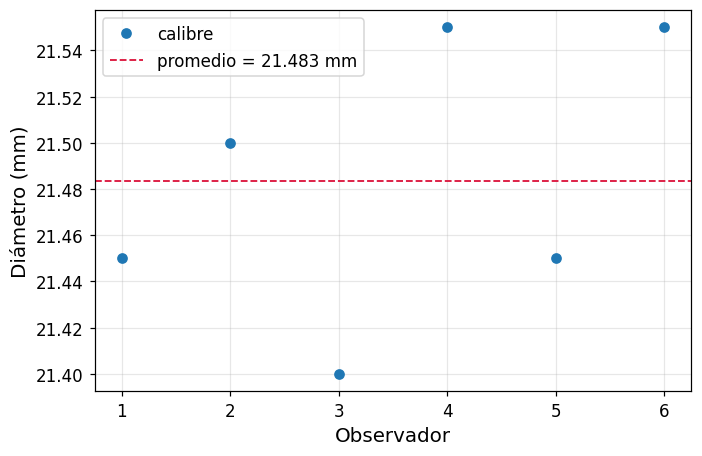

In [7]:
observador = np.arange(1, len(calibre) + 1)

fig, ax = plt.subplots()
ax.plot(observador, calibre, "o", label="calibre")
ax.axhline(calibre.mean(), color="crimson", ls="--", lw=1.2,
           label=f"promedio = {calibre.mean():.3f} mm")
ax.set_xlabel("Observador")
ax.set_ylabel("Diámetro (mm)")
ax.set_xticks(observador)
ax.legend()
plt.show()

Notá tres decisiones deliberadas: marcadores `"o"` **sin línea**, ejes con
magnitud y unidad, y las marcas del eje x en los enteros, porque "observador
2,5" no existe.

Para el informe, la figura se guarda en archivo. El PDF es vectorial y no se
pixela al ampliarlo; el PNG sirve para pegar rápido en un borrador.

In [ ]:
lab.guardar_figura("mediciones_calibre", fig)

### 6. ¿Cuántos dígitos escribo?

`21.483333333333334` no es un resultado, es lo que devuelve la máquina. Un
resultado experimental se escribe con **la cantidad de cifras que la incerteza
justifica**, y ni una más. La regla completa la vemos en la Clase 2, cuando
tengamos una incerteza calculada; por ahora, la versión mínima:

> Nunca escribas más cifras significativas que las que distingue tu
> instrumento.

Con el calibre (resolución 0,05 mm) informar `21,4625 mm` es afirmar que
distinguís décimas de micrón con una herramienta que aprecia 50 micrones.

In [ ]:
promedio_crudo = calibre.mean()

print("lo que devuelve la máquina:", promedio_crudo)
print(f"lo que corresponde escribir: {promedio_crudo:.2f} mm")

### 7. Ejercicios

1. Cargá las mediciones **de tu grupo** en lugar de las de ejemplo y rehacé
   el cuadro comparativo de la sección 4. ¿Con cuál de los tres instrumentos
   la dispersión entre personas supera a la resolución?
2. Graficá los tres conjuntos en una misma figura. Vas a necesitar llamar
   `ax.plot` tres veces antes de `plt.show()`. Elegí marcadores distintos
   (`"o"`, `"s"`, `"^"`).
3. Calculá el volumen del cilindro a partir del diámetro y la altura
   promedio. ¿Cuántas cifras escribirías en el resultado? Guardá tu respuesta
   por escrito: en la Clase 4 vamos a calcular la incerteza de ese volumen y
   vas a poder verificar si acertaste.
4. **Trampa deliberada:** ejecutá `np.array([1, 2, 3]) / 2` y después
   `np.array([1, 2, 3]) // 2`. Explicá la diferencia.

In [ ]:
# Espacio de trabajo para los ejercicios.

### Para tu carpeta

- Las mediciones crudas van al **cuaderno de laboratorio**, no solo al Colab.
  El cuaderno es la fuente primaria; esto es el análisis.
- La figura exportada en PDF.
- La respuesta escrita al ejercicio 3.